# Proyecto Intermedio de Introducción al Aprendizaje Automático

**Comparación de Algoritmos: KNN, Árboles de Decisión y Random Forest**

**Dataset:** [NBA Dataset – Kaggle (brandonrollins)](https://www.kaggle.com/datasets/brandonrollins/nba-dataset)

**Problema de Clasificación:** Predecir si un equipo de la NBA ganó o perdió un partido (`win`) a partir de sus estadísticas de rendimiento durante el juego (tiros, rebotes, asistencias, robos, pérdidas, etc.).

## 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Carga y Exploración del Dataset

In [2]:
df = pd.read_csv('TeamStatistics.csv', low_memory=False)
print(f'Dimensiones originales: {df.shape}')
print(f'Registros: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Dimensiones originales: (144614, 48)
Registros: 144,614 | Columnas: 48


,gameId,gameDateTimeEst,teamCity,teamName,teamId,opponentTeamCity,opponentTeamName,opponentTeamId,home,win,...,leadChanges,pointsFastBreak,pointsFromTurnovers,pointsInThePaint,pointsSecondChance,timesTied,timeoutsRemaining,seasonWins,seasonLosses,coachId
0,22500366,2025-12-08 15:00:00,New Orleans,Pelicans,1610612740,San Antonio,Spurs,1610612759,1,0,...,13.0,16.0,17.0,84.0,6.0,11.0,0.0,3.0,22.0,NaN
1,22500366,2025-12-08 15:00:00,San Antonio,Spurs,1610612759,New Orleans,Pelicans,1610612740,0,1,...,13.0,22.0,16.0,62.0,18.0,11.0,0.0,16.0,7.0,NaN
2,22500365,2025-12-08 14:30:00,Minnesota,Timberwolves,1610612750,Phoenix,Suns,1610612756,1,0,...,2.0,9.0,14.0,40.0,20.0,6.0,0.0,15.0,9.0,NaN
3,22500365,2025-12-08 14:30:00,Phoenix,Suns,1610612756,Minnesota,Timberwolves,1610612750,0,1,...,2.0,5.0,24.0,50.0,10.0,6.0,0.0,14.0,10.0,NaN
4,22500364,2025-12-08 14:00:00,Indiana,Pacers,1610612754,Sacramento,Kings,1610612758,1,1,...,4.0,12.0,17.0,34.0,11.0,6.0,0.0,6.0,18.0,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144614 entries, 0 to 144613
Data columns (total 48 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   gameId                   144614 non-null  int64  
 1   gameDateTimeEst          144614 non-null  object 
 2   teamCity                 144614 non-null  object 
 3   teamName                 144614 non-null  object 
 4   teamId                   144614 non-null  int64  
 5   opponentTeamCity         144614 non-null  object 
 6   opponentTeamName         144614 non-null  object 
 7   opponentTeamId           144614 non-null  int64  
 8   home                     144614 non-null  int64  
 9   win                      144614 non-null  int64  
 10  teamScore                144614 non-null  int64  
 11  opponentScore            144614 non-null  int64  
 12  assists                  109527 non-null  float64
 13  blocks                   103913 non-null  float64
 14  stea

In [4]:
print('Distribución de la variable objetivo (win):')
print(df['win'].value_counts())
print(f'\nBalance: {df["win"].value_counts(normalize=True).to_dict()}')

Distribución de la variable objetivo (win):
win
0    72307
1    72307
Name: count, dtype: int64

Balance: {0: 0.5, 1: 0.5}


## 3. Limpieza y Selección de Características

In [5]:
features = [
    'home',
    'assists', 'blocks', 'steals',
    'fieldGoalsAttempted', 'fieldGoalsMade', 'fieldGoalsPercentage',
    'threePointersAttempted', 'threePointersMade', 'threePointersPercentage',
    'freeThrowsAttempted', 'freeThrowsMade', 'freeThrowsPercentage',
    'reboundsDefensive', 'reboundsOffensive', 'reboundsTotal',
    'foulsPersonal', 'turnovers'
]

target = 'win'

df_model = df[features + [target]].copy()
print(f'Forma antes de limpiar nulos: {df_model.shape}')

df_model.dropna(inplace=True)
print(f'Forma después de limpiar nulos: {df_model.shape}')
print(f'\nNulos restantes: {df_model.isnull().sum().sum()}')

Forma antes de limpiar nulos: (144614, 19)
Forma después de limpiar nulos: (102551, 19)

Nulos restantes: 0


In [6]:
print('Estadísticas descriptivas de las características seleccionadas:\n')
df_model.describe().round(2)

Estadísticas descriptivas de las características seleccionadas:



,home,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,fieldGoalsPercentage,threePointersAttempted,threePointersMade,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,win
count,102551.0,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.00,102551.0
mean,0.5,23.00,4.99,7.90,83.77,38.45,0.46,19.18,6.79,0.34,25.09,18.99,0.76,30.96,11.79,42.75,21.71,14.86,0.5
std,0.5,5.53,2.64,3.05,8.50,5.80,0.06,11.04,4.59,0.14,8.12,6.55,0.10,5.63,4.32,6.75,4.80,4.18,0.5
min,0.0,4.00,0.00,0.00,29.00,9.00,0.23,1.00,0.00,0.00,1.00,0.00,0.00,3.00,0.00,15.00,4.00,0.00,0.0
25%,0.0,19.00,3.00,6.00,78.00,34.00,0.42,11.00,3.00,0.26,19.00,14.00,0.69,27.00,9.00,38.00,18.00,12.00,0.0
50%,0.0,23.00,5.00,8.00,83.00,38.00,0.46,17.00,6.00,0.34,24.00,18.00,0.76,31.00,11.00,42.00,21.00,15.00,0.0
75%,1.0,27.00,7.00,10.00,89.00,42.00,0.50,26.00,10.00,0.43,30.00,23.00,0.83,35.00,14.00,47.00,25.00,18.00,1.0
max,1.0,52.00,23.00,27.00,130.00,68.00,0.70,70.00,29.00,1.00,80.00,61.00,1.00,60.00,44.00,81.00,52.00,40.00,1.0


### Análisis Exploratorio (EDA)

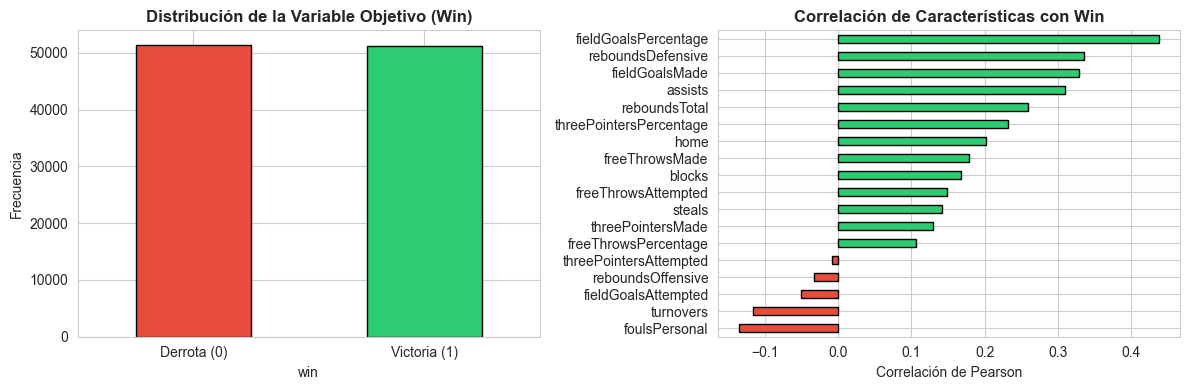

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de la variable objetivo
colors = ['#e74c3c', '#2ecc71']
df_model[target].value_counts().plot.bar(ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribución de la Variable Objetivo (Win)', fontweight='bold')
axes[0].set_xticklabels(['Derrota (0)', 'Victoria (1)'], rotation=0)
axes[0].set_ylabel('Frecuencia')

# Correlación con la variable objetivo
corr_with_target = df_model.corr()[target].drop(target).sort_values()
corr_with_target.plot.barh(ax=axes[1], color=corr_with_target.apply(
    lambda x: '#2ecc71' if x > 0 else '#e74c3c'), edgecolor='black')
axes[1].set_title('Correlación de Características con Win', fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.show()

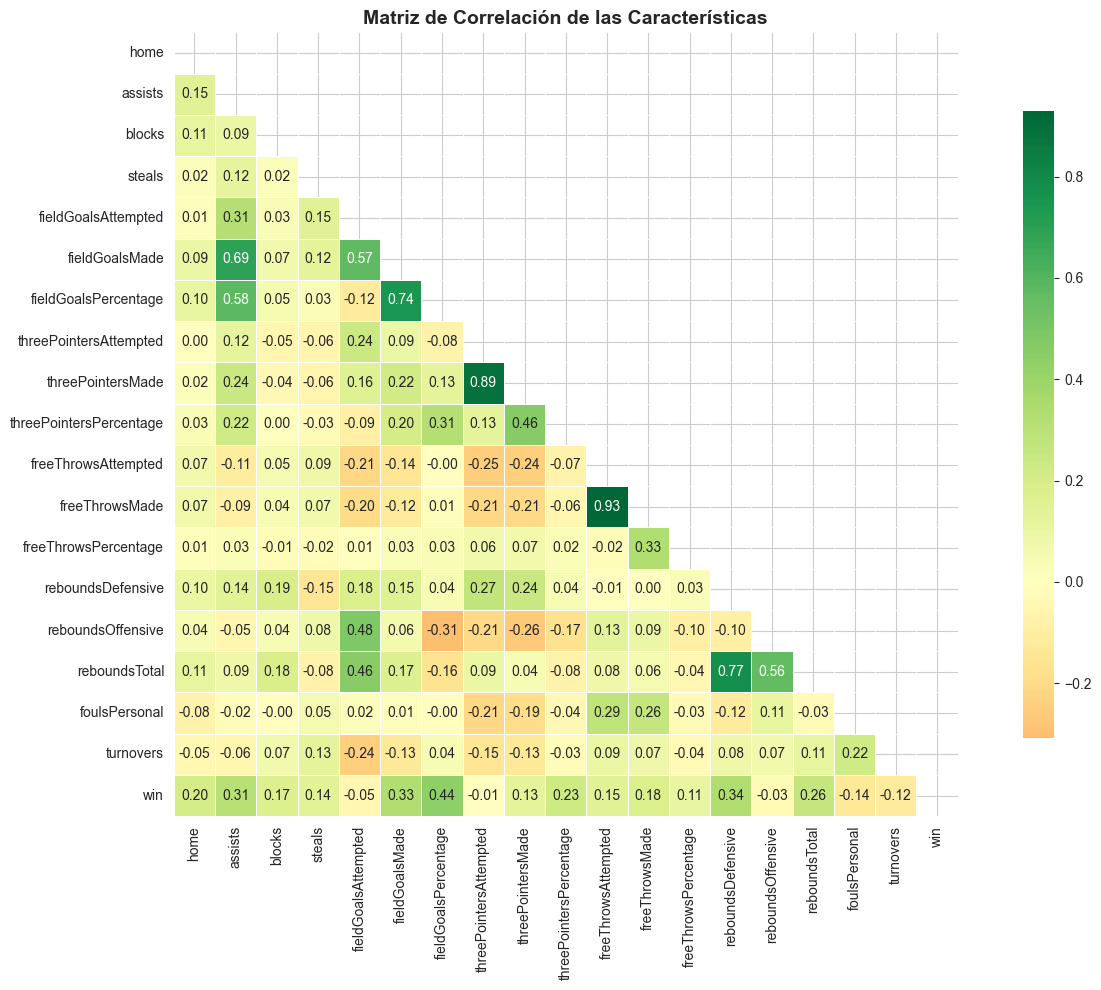

In [8]:
plt.figure(figsize=(14, 10))
corr_matrix = df_model.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación de las Características', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. División de Datos (80% Entrenamiento – 20% Prueba)

In [9]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]:,} registros')
print(f'Conjunto de prueba:        {X_test.shape[0]:,} registros')
print(f'\nProporciones en entrenamiento:')
print(y_train.value_counts(normalize=True).round(4))
print(f'\nProporciones en prueba:')
print(y_test.value_counts(normalize=True).round(4))

Conjunto de entrenamiento: 82,040 registros
Conjunto de prueba:        20,511 registros

Proporciones en entrenamiento:
win
0    0.5012
1    0.4988
Name: proportion, dtype: float64

Proporciones en prueba:
win
0    0.5012
1    0.4988
Name: proportion, dtype: float64


### Escalamiento de Características

KNN es sensible a la escala de los datos, por lo que aplicamos **StandardScaler** para normalizar las características.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Escalamiento aplicado con StandardScaler.')
print(f'Media (train, primeras 5 features): {X_train_scaled[:, :5].mean(axis=0).round(6)}')
print(f'Std   (train, primeras 5 features): {X_train_scaled[:, :5].std(axis=0).round(6)}')

Escalamiento aplicado con StandardScaler.
Media (train, primeras 5 features): [ 0.  0. -0.  0.  0.]
Std   (train, primeras 5 features): [1. 1. 1. 1. 1.]


## 5. Implementación y Entrenamiento de los Modelos

### 5.1 K-Nearest Neighbors (KNN)

In [11]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2  # equivalente a distancia euclidiana
)

start_time = time.time()
knn.fit(X_train_scaled, y_train)
knn_train_time = time.time() - start_time

y_pred_knn = knn.predict(X_test_scaled)

print(f'KNN entrenado exitosamente.')
print(f'Hiperparámetros: n_neighbors=5, metric=minkowski (p=2, euclidiana)')
print(f'Tiempo de entrenamiento: {knn_train_time:.6f} segundos')
print(f'\nReporte de Clasificación:\n')
print(classification_report(y_test, y_pred_knn, target_names=['Derrota', 'Victoria']))

KNN entrenado exitosamente.
Hiperparámetros: n_neighbors=5, metric=minkowski (p=2, euclidiana)
Tiempo de entrenamiento: 0.003124 segundos

Reporte de Clasificación:

              precision    recall  f1-score   support

     Derrota       0.78      0.79      0.79     10280
    Victoria       0.79      0.78      0.78     10231

    accuracy                           0.78     20511
   macro avg       0.78      0.78      0.78     20511
weighted avg       0.78      0.78      0.78     20511



### 5.2 Árbol de Decisión

In [12]:
dt = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=42
)

start_time = time.time()
dt.fit(X_train_scaled, y_train)
dt_train_time = time.time() - start_time

y_pred_dt = dt.predict(X_test_scaled)

print(f'Árbol de Decisión entrenado exitosamente.')
print(f'Hiperparámetros: max_depth=5, criterion=gini')
print(f'Tiempo de entrenamiento: {dt_train_time:.6f} segundos')
print(f'\nReporte de Clasificación:\n')
print(classification_report(y_test, y_pred_dt, target_names=['Derrota', 'Victoria']))

Árbol de Decisión entrenado exitosamente.
Hiperparámetros: max_depth=5, criterion=gini
Tiempo de entrenamiento: 0.175781 segundos

Reporte de Clasificación:

              precision    recall  f1-score   support

     Derrota       0.74      0.75      0.75     10280
    Victoria       0.75      0.74      0.74     10231

    accuracy                           0.74     20511
   macro avg       0.74      0.74      0.74     20511
weighted avg       0.74      0.74      0.74     20511



### 5.3 Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start_time = time.time()
rf.fit(X_train_scaled, y_train)
rf_train_time = time.time() - start_time

y_pred_rf = rf.predict(X_test_scaled)

print(f'Random Forest entrenado exitosamente.')
print(f'Hiperparámetros: n_estimators=100')
print(f'Tiempo de entrenamiento: {rf_train_time:.6f} segundos')
print(f'\nReporte de Clasificación:\n')
print(classification_report(y_test, y_pred_rf, target_names=['Derrota', 'Victoria']))

Random Forest entrenado exitosamente.
Hiperparámetros: n_estimators=100
Tiempo de entrenamiento: 10.041296 segundos

Reporte de Clasificación:

              precision    recall  f1-score   support

     Derrota       0.82      0.83      0.82     10280
    Victoria       0.83      0.82      0.82     10231

    accuracy                           0.82     20511
   macro avg       0.82      0.82      0.82     20511
weighted avg       0.82      0.82      0.82     20511



## 6. Evaluación y Comparación de Modelos

### 6.1 Tabla Comparativa de Métricas

In [14]:
modelos = {
    'KNN (k=5, Minkowski)': (y_pred_knn, knn_train_time),
    'Árbol de Decisión (depth=5, Gini)': (y_pred_dt, dt_train_time),
    'Random Forest (100 árboles)': (y_pred_rf, rf_train_time)
}

resultados = []
for nombre, (y_pred, t_time) in modelos.items():
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Tiempo Entrenamiento (s)': t_time
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.set_index('Modelo', inplace=True)

print('=' * 80)
print('TABLA COMPARATIVA DE RESULTADOS')
print('=' * 80)
print(df_resultados.to_string())
print('=' * 80)

TABLA COMPARATIVA DE RESULTADOS
                                   Accuracy    Recall  F1-Score  Tiempo Entrenamiento (s)
Modelo                                                                                   
KNN (k=5, Minkowski)               0.784750  0.779787  0.783270                  0.003124
Árbol de Decisión (depth=5, Gini)  0.743552  0.736585  0.741295                  0.175781
Random Forest (100 árboles)        0.823217  0.815267  0.821450                 10.041296


In [15]:
df_display = df_resultados.copy()
df_display['Accuracy'] = df_display['Accuracy'].apply(lambda x: f'{x:.4f}')
df_display['Recall'] = df_display['Recall'].apply(lambda x: f'{x:.4f}')
df_display['F1-Score'] = df_display['F1-Score'].apply(lambda x: f'{x:.4f}')
df_display['Tiempo Entrenamiento (s)'] = df_display['Tiempo Entrenamiento (s)'].apply(lambda x: f'{x:.6f}')
df_display

,Accuracy,Recall,F1-Score,Tiempo Entrenamiento (s)
Modelo,,,,
"KNN (k=5, Minkowski)",0.7847,0.7798,0.7833,0.003124
"Árbol de Decisión (depth=5, Gini)",0.7436,0.7366,0.7413,0.175781
Random Forest (100 árboles),0.8232,0.8153,0.8214,10.041296


### 6.2 Matrices de Confusión

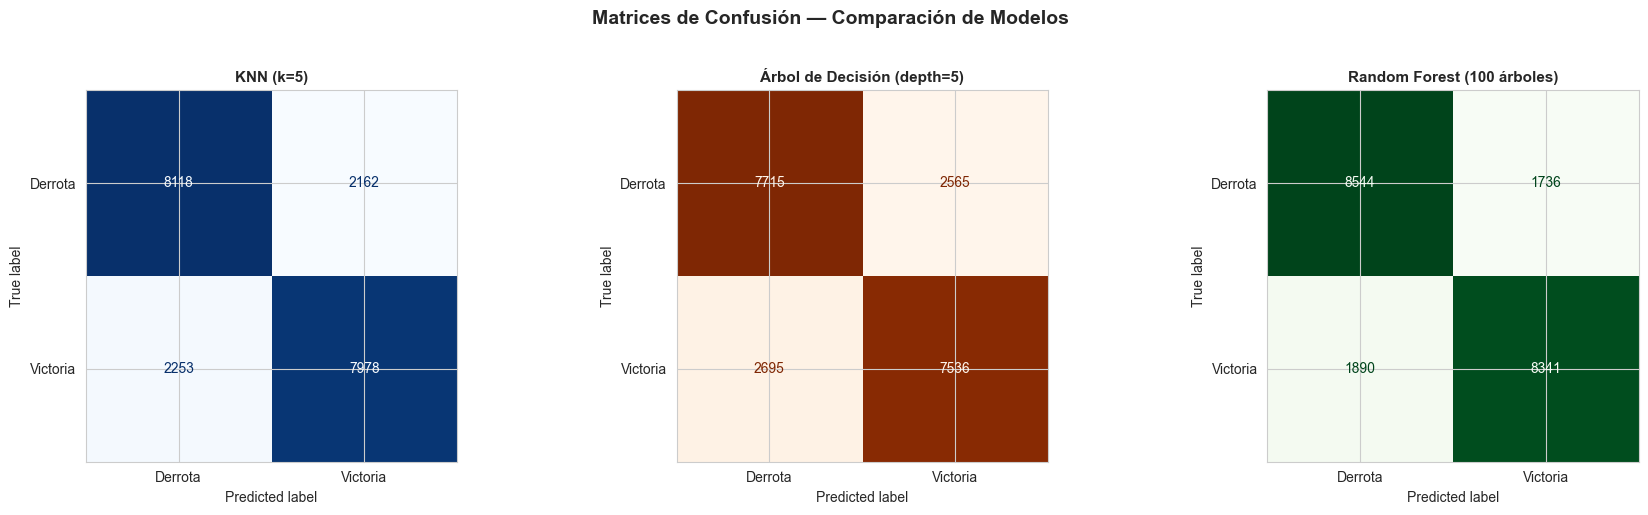

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

nombres = ['KNN (k=5)', 'Árbol de Decisión (depth=5)', 'Random Forest (100 árboles)']
predicciones = [y_pred_knn, y_pred_dt, y_pred_rf]
colores = ['Blues', 'Oranges', 'Greens']

for ax, nombre, y_pred, cmap in zip(axes, nombres, predicciones, colores):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Derrota', 'Victoria'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(nombre, fontweight='bold', fontsize=11)

plt.suptitle('Matrices de Confusión — Comparación de Modelos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Comparación Visual de Métricas

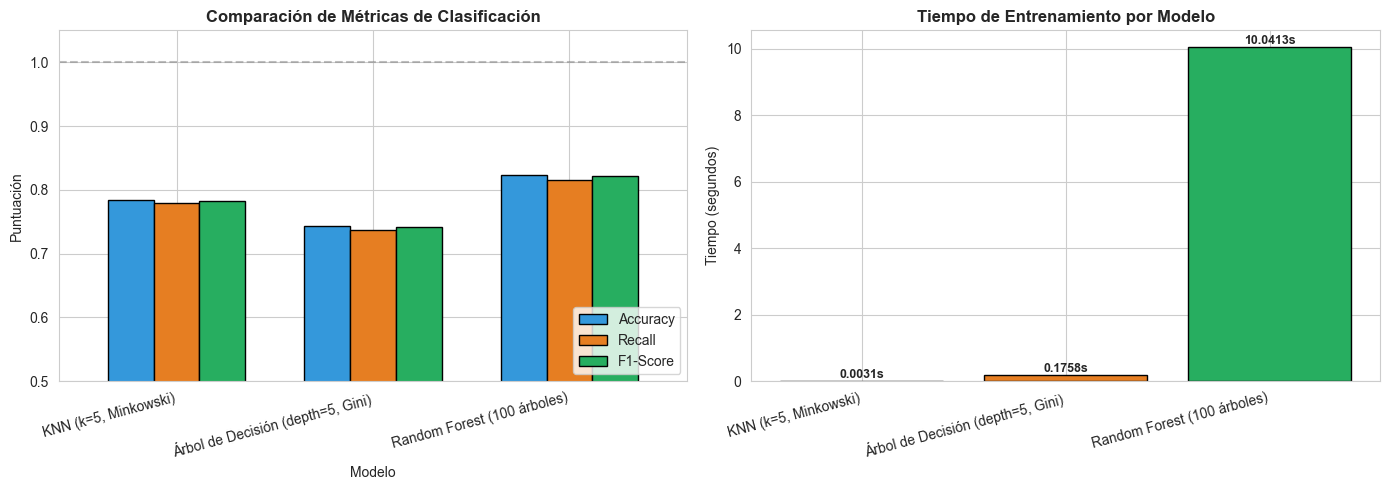

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas = ['Accuracy', 'Recall', 'F1-Score']
df_metricas = df_resultados[metricas]

bar_colors = ['#3498db', '#e67e22', '#27ae60']
df_metricas.plot.bar(ax=axes[0], color=bar_colors, edgecolor='black', width=0.7)
axes[0].set_title('Comparación de Métricas de Clasificación', fontweight='bold')
axes[0].set_ylabel('Puntuación')
axes[0].set_ylim(0.5, 1.05)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].legend(loc='lower right')
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

tiempos = df_resultados['Tiempo Entrenamiento (s)']
bars = axes[1].bar(tiempos.index, tiempos.values, color=['#3498db', '#e67e22', '#27ae60'],
                   edgecolor='black')
axes[1].set_title('Tiempo de Entrenamiento por Modelo', fontweight='bold')
axes[1].set_ylabel('Tiempo (segundos)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

for bar, val in zip(bars, tiempos.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.4 Importancia de Características (Random Forest)

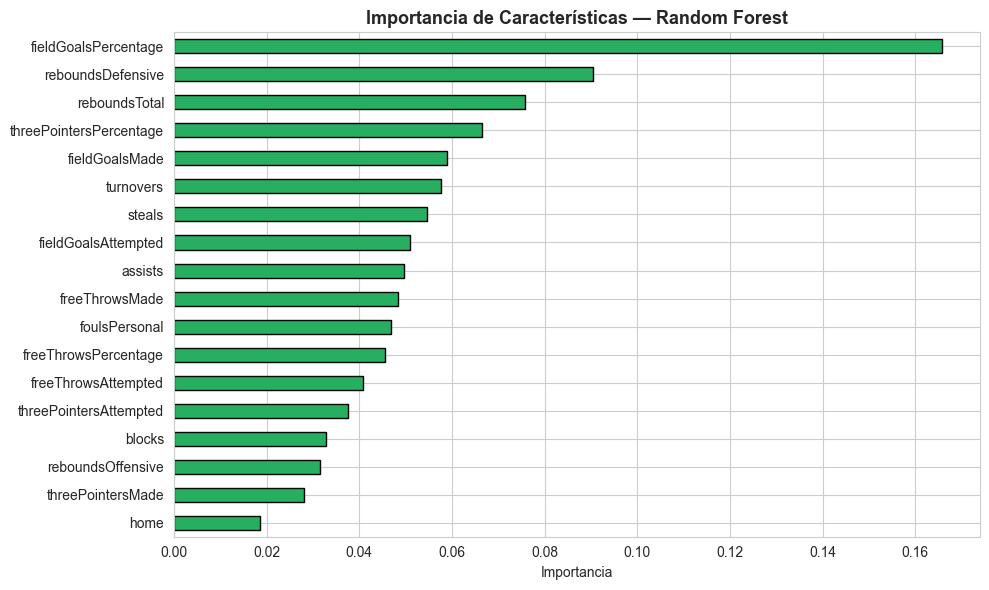

In [18]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot.barh(color='#27ae60', edgecolor='black')
plt.title('Importancia de Características — Random Forest', fontweight='bold', fontsize=13)
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

### 6.5 Generación de la Tabla en Formato Markdown (para el reporte)

In [19]:
print('Tabla para copiar al reporte Markdown:\n')
print(df_display.to_markdown())

print('\n\nMatrices de Confusión para el reporte:\n')
for nombre, y_pred in zip(nombres, predicciones):
    cm = confusion_matrix(y_test, y_pred)
    print(f'**{nombre}:**')
    print(f'  | | Pred. Derrota | Pred. Victoria |')
    print(f'  |---|---|---|')
    print(f'  | **Real Derrota** | {cm[0][0]} | {cm[0][1]} |')
    print(f'  | **Real Victoria** | {cm[1][0]} | {cm[1][1]} |')
    print()

Tabla para copiar al reporte Markdown:

| Modelo                            |   Accuracy |   Recall |   F1-Score |   Tiempo Entrenamiento (s) |
|:----------------------------------|-----------:|---------:|-----------:|---------------------------:|
| KNN (k=5, Minkowski)              |     0.7847 |   0.7798 |     0.7833 |                   0.003124 |
| Árbol de Decisión (depth=5, Gini) |     0.7436 |   0.7366 |     0.7413 |                   0.175781 |
| Random Forest (100 árboles)       |     0.8232 |   0.8153 |     0.8214 |                  10.0413   |


Matrices de Confusión para el reporte:

**KNN (k=5):**
  | | Pred. Derrota | Pred. Victoria |
  |---|---|---|
  | **Real Derrota** | 8118 | 2162 |
  | **Real Victoria** | 2253 | 7978 |

**Árbol de Decisión (depth=5):**
  | | Pred. Derrota | Pred. Victoria |
  |---|---|---|
  | **Real Derrota** | 7715 | 2565 |
  | **Real Victoria** | 2695 | 7536 |

**Random Forest (100 árboles):**
  | | Pred. Derrota | Pred. Victoria |
  |---|---|---|


---

**Fin de la Fase 1.** Los resultados obtenidos en este notebook se utilizan para elaborar el Reporte Markdown (Fase 2).